In [1]:
#LOADING MAIN LIBRARIES
import xarray as xr
import numpy as np
import matplotlib
# matplotlib.use("Agg") #figures are not sent to the Jupyter frontend #*#* (turn off if wanting to see plots in Notebook)
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from tqdm import tqdm

import os

In [2]:
#SETTING UP MAIN DIRECTORIES
mainDirectory = "/glade/u/home/aroseman/Projects/Regional-MPAS-Project/Code/CodeFiles/"

In [3]:
#DIRECTORY FUNCTIONS
def ListFiles(directory, n=10):
    files = os.listdir(directory)
    # print("Listing first", n, "files:\n", files[:n], "\n")
    return files

In [4]:
#LOADING CLASSES
# --- Add your Functions folder to sys.path ---
import sys
path = mainDirectory + '/Functions_2.0/Classes'
sys.path.append(path)

# --- Import all your function modules ---
import importlib
modules = [
    "Classes_MapPlotting"
]

for mod in modules:
    globals()[mod] = importlib.import_module(mod)        # import module itself
    globals().update(vars(globals()[mod]))              # import all functions into global namespace

In [5]:
################################################################################

In [7]:
#DATA DESCRIPTIONS

### Data Type
# VDIS Video Disdrometer

### Link
# https://armgov.svcs.arm.gov/capabilities/instruments/vdis

### Summary
# A disdrometer measures the drop size distribution and velocity of falling hydrometeors.
# The 2-dimensional video-disdrometer (VDIS) comprises video cameras capable of observing 
# individual hydrometeors from views perpendicular to each other. 
# Two CCD line scan cameras are directed towards the measurement area. 
# Objects passing through the measurement area—which is determined by the 
# cross-section of the two optical paths as seen from above—obstruct the light 
# and are detected as shadows by the cameras.


### Temporal Coverage
# Begin datetime	2022-05-25 00:00:00
# End datetime	2021-10-01 00:30:00

### Spatial Coverage
# Located at TRACER ARM M1 Facility at (29.67N, 95.059W)

In [8]:
################################################################################

In [31]:
#SET UP DIRECTORIES
Campaign="TRACER"
DataType="Video_Disdrometer"

#Code Directory
Code_Directory="/glade/u/home/aroseman/Projects/Regional-MPAS-Project/Code/CodeFiles/DataAnalysis/Observation_Data"
Code_Directory=os.path.join(Code_Directory,Campaign)
print("Code Directory Set as:", Code_Directory, '\n')

def GetDataDirectory(Campaign=Campaign,
                     DataType=DataType,
                     BaseDir="/glade/work/aroseman/Projects/Regional-MPAS-Project/Code/DATA/Observation_Data"):
    #old base directory: BaseDir="/glade/derecho/scratch/aroseman/Projects/Regional-MPAS-Project/Code/DATA/Observation_Data"
    Data_Directory = os.path.join(BaseDir, Campaign, DataType)
    print("Data Directory Set as:", Data_Directory, '\n')
    FileList = np.sort(ListFiles(Data_Directory))
    return Data_Directory, FileList

#Output Directory
Output_Directory="/glade/u/home/aroseman/Projects/Regional-MPAS-Project/Code/OUTPUT/DataAnalysis/Observation_Data"
Output_Directory=os.path.join(Output_Directory,Campaign,DataType)

Code Directory Set as: /glade/u/home/aroseman/Projects/Regional-MPAS-Project/Code/CodeFiles/DataAnalysis/Observation_Data/TRACER 



In [9]:
#READING DATA FUNCTIONS
###################################

In [34]:
import xarray as xr
def GetData(Data_Directory, FileList, index):
    DataFile = os.path.join(Data_Directory,FileList[index])
    # print(f"Downloading File:\n {DataFile}","\n")
    DataNC = xr.open_dataset(DataFile,decode_timedelta=True)
    return DataNC, DataFile

In [35]:
import pandas as pd
def subset_time(data, start_date, end_date, buffer="1D", time_name="time"):
    """
    Subset an xarray Dataset/DataArray between two dates with optional buffer.

    Parameters
    ----------
    data : xr.Dataset or xr.DataArray
        Input data with a time coordinate.
    start_date : str or datetime-like
        Start of range (e.g., "2022-06-30").
    end_date : str or datetime-like
        End of range (e.g., "2022-07-03").
    buffer : str or pd.Timedelta, optional
        Extra padding before/after range (default "1D", e.g., "6H").
    time_name : str, optional
        Name of time dimension (default "time").

    Returns
    -------
    xr.Dataset or xr.DataArray
        Subset of the input data in the requested time window.
    """
    start = pd.to_datetime(start_date) - pd.Timedelta(buffer)
    end   = pd.to_datetime(end_date)   + pd.Timedelta(buffer)
    return data.sel({time_name: slice(start, end)})
    
def subset_until_date(data, target_date, time_name="time"):
    """
    Select all data up to and including the first timestamp 
    on the given target_date.

    Parameters
    ----------
    data : xr.Dataset or xr.DataArray
        Input data with a time coordinate.
    target_date : str or np.datetime64
        Date (YYYY-MM-DD) to stop at.
    time_name : str, optional
        Name of the time dimension. Default is 'time'.

    Returns
    -------
    xr.Dataset or xr.DataArray
        Subset of the data up to the first timestamp on target_date.
    """
    times = pd.to_datetime(data[time_name].values)
    target_date = pd.to_datetime(target_date).date()

    # Find first index where the date matches
    idx = np.where(times.date == target_date)[0][0]

    # Slice everything up to and including that index
    return data.isel({time_name: slice(0, idx+1)})

In [36]:
#READING DATA
###################################

In [54]:
#GETTING DATA
[Data_Directory, FileList] = GetDataDirectory()
[DataNC, DataFile] = GetData(Data_Directory, FileList, index=263) #index 0 = 2021, index 1 = 2022
print(DataFile)

Data Directory Set as: /glade/work/aroseman/Projects/Regional-MPAS-Project/Code/DATA/Observation_Data/TRACER/Video_Disdrometer 

/glade/work/aroseman/Projects/Regional-MPAS-Project/Code/DATA/Observation_Data/TRACER/Video_Disdrometer/houvdisM1.b1.20220630.000000.cdf


In [55]:
DataNC.data_vars

Data variables:
    base_time                          datetime64[ns] 8B ...
    time_offset                        (time) datetime64[ns] 12kB ...
    num_drops                          (time, drop_diameter) float64 576kB ...
    qc_num_drops                       (time, drop_diameter) int32 288kB ...
    num_density                        (time, drop_diameter) float32 288kB ...
    qc_num_density                     (time, drop_diameter) int32 288kB ...
    rain_rate                          (time) float32 6kB ...
    qc_rain_rate                       (time) int32 6kB ...
    rain_amount                        (time) float32 6kB ...
    qc_rain_amount                     (time) int32 6kB ...
    total_drops                        (time) float64 12kB ...
    qc_total_drops                     (time) int32 6kB ...
    liquid_water_content               (time) float32 6kB ...
    qc_liquid_water_content            (time) int32 6kB ...
    intercept_parameter                (time) float3

In [56]:
#PLOTTING DATA FUNCTIONS
###################################

In [69]:
def PlotVariable_TZ(variable):
    # DataNC_subset[variable].T.plot()
    DataNC[variable].T.dropna(dim="time", how="all").plot()

import matplotlib.pyplot as plt
import numpy as np

def PlotVariable_TZ(variable, ax=None):
    """
    Plot a variable from DataNC (transpose + dropna).
    """
    if ax is None:
        fig, ax = plt.subplots()
    DataNC[variable].T.dropna(dim="time", how="all").plot(ax=ax)
    ax.set_title(variable)


def plot_variable_list(var_list, ncols=4):
    """
    Plot a list of variables in a grid of subplots.

    Parameters
    ----------
    var_list : list of str
        Variables to plot from DataNC
    ncols : int
        Number of subplot columns
    """
    nplots = len(var_list)
    nrows = int(np.ceil(nplots / ncols))

    fig, axes = plt.subplots(nrows=nrows, ncols=ncols,
                             figsize=(5*ncols, 3*nrows),
                             squeeze=False)

    for i, var in enumerate(var_list):
        ax = axes[i // ncols, i % ncols]
        try:
            PlotVariable_TZ(var, ax=ax)
        except Exception as e:
            ax.set_title(f"{var} (failed)")
            print(f"Skipping {var}: {e}")

    # Remove unused axes
    for j in range(i+1, nrows*ncols):
        fig.delaxes(axes[j // ncols, j % ncols])

    plt.tight_layout()
    plt.show()


In [70]:
#PLOTTING DATA
###################################

In [71]:
drop_spectrum_vars = [
    "num_drops",          # raw counts per diameter bin
    "num_density",        # number density per diameter bin
]


In [72]:
rain_bulk_vars = [
    "rain_rate",          # mm/hr or similar
    "rain_amount",        # accumulated amount
    "total_drops",        # integrated over bins
    "liquid_water_content",
]


In [73]:
distribution_fit_vars = [
    "intercept_parameter",            # N0
    "slope_parameter",                # Λ
    "median_volume_diameter",         # D0
    "liquid_water_distribution_mean", # mean of LWC distribution
    "diameter_min",
    "diameter_max",
]


In [74]:
moment_vars = [
    "moment1",
    "moment2",
    "moment3",
    "moment4",
    "moment5",
    "moment6",
]


In [75]:
radar_vars = [
    "radar_reflectivity",
]

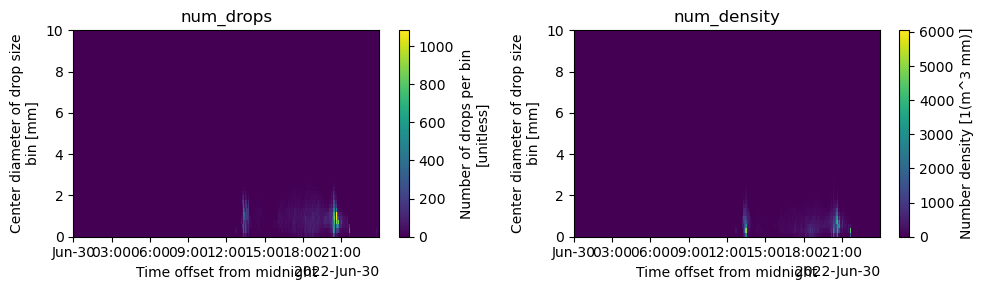

In [83]:
plot_variable_list(drop_spectrum_vars,ncols=2)

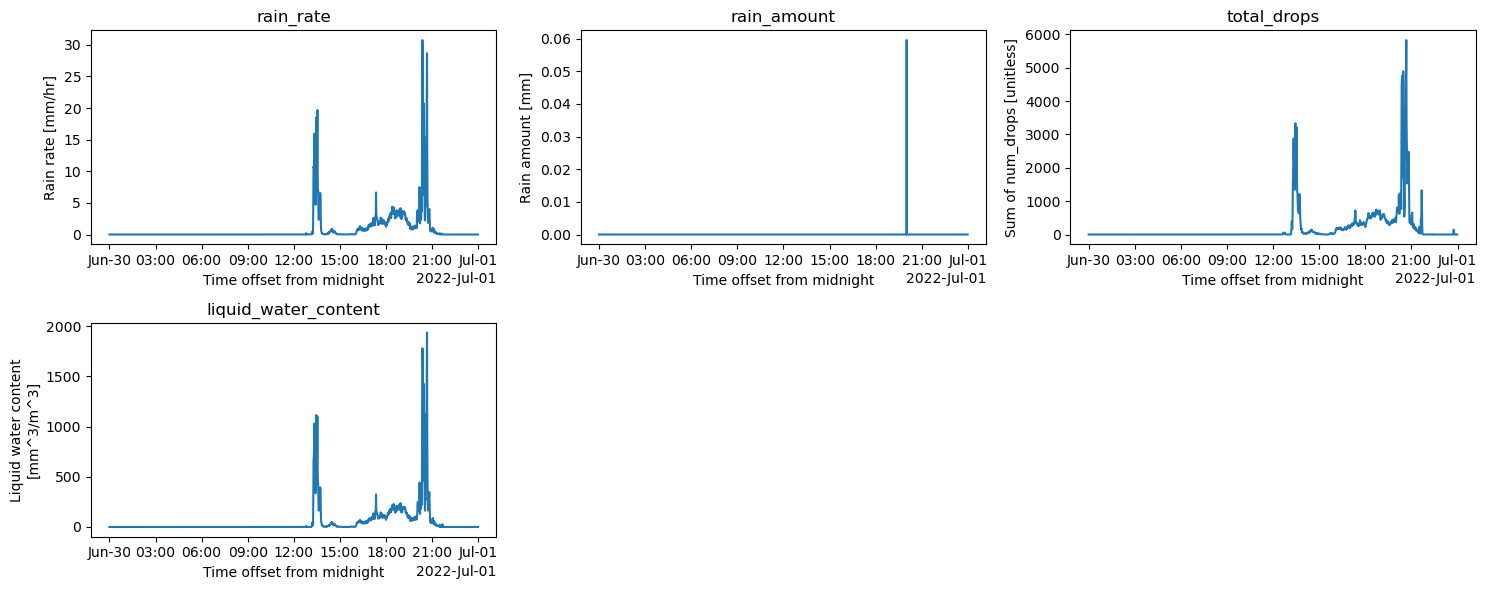

In [82]:
plot_variable_list(rain_bulk_vars,ncols=3)

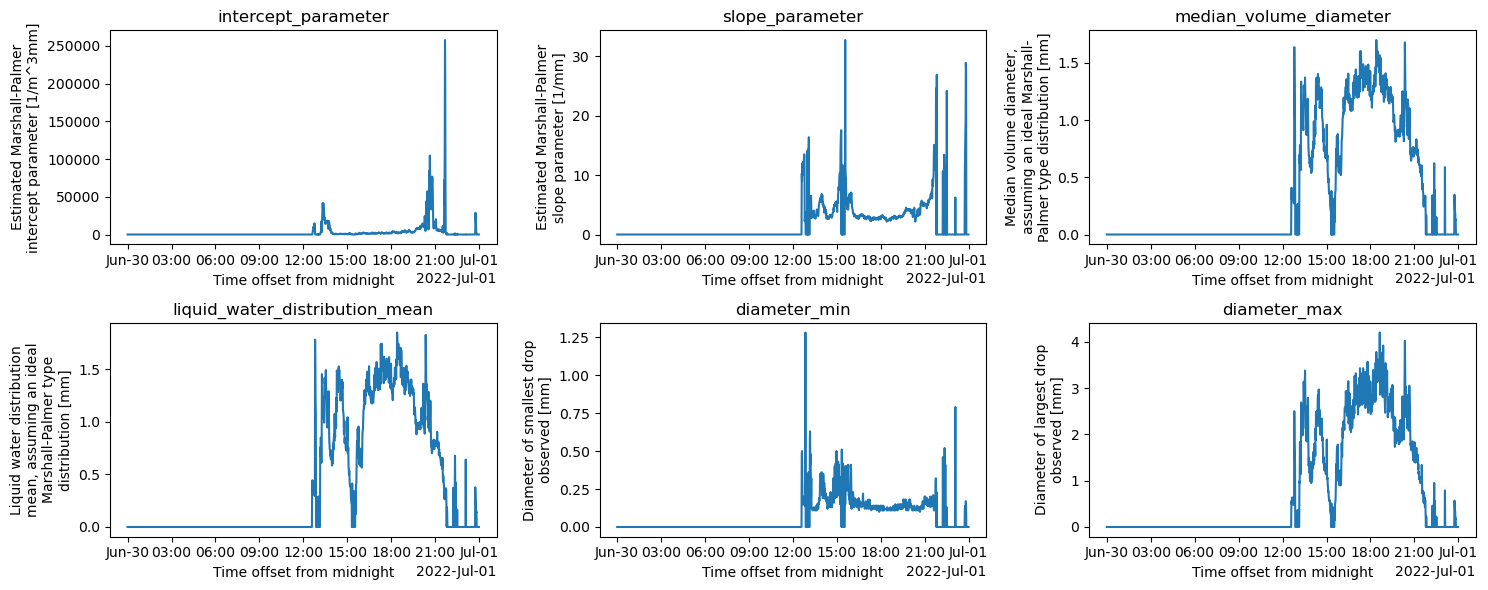

In [81]:
plot_variable_list(distribution_fit_vars,ncols=3)

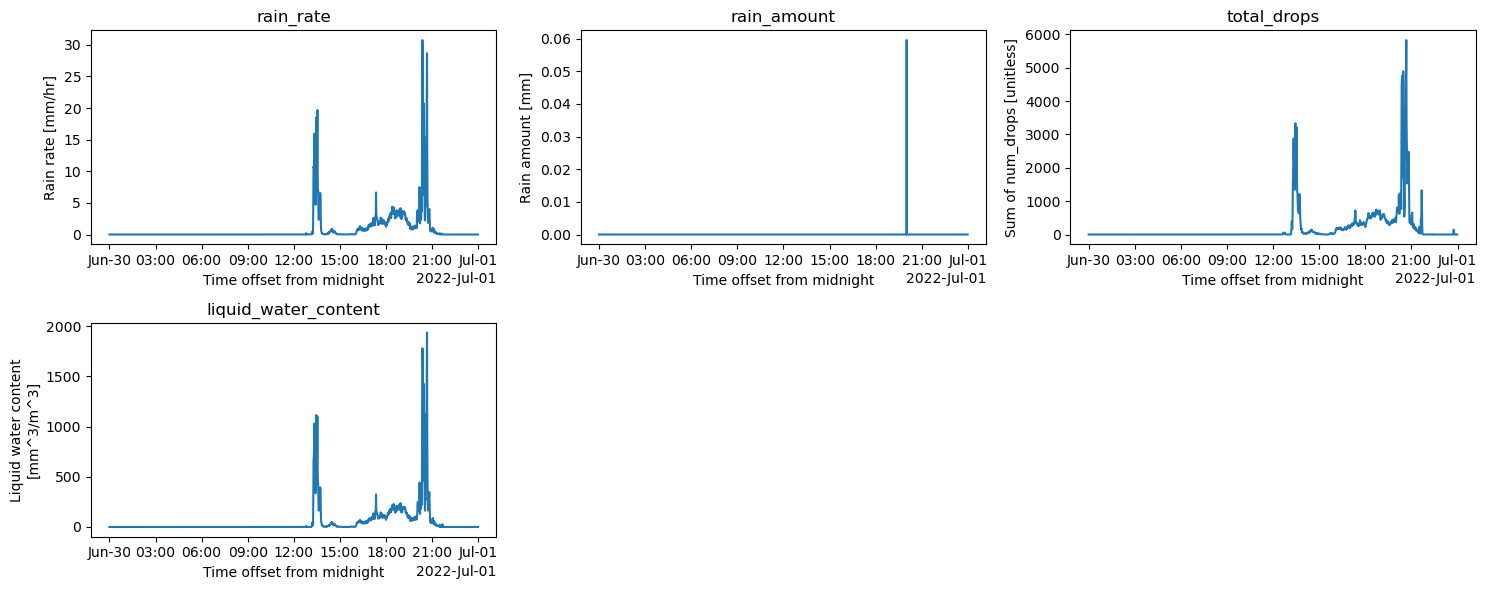

In [77]:
plot_variable_list(rain_bulk_vars, ncols=3)

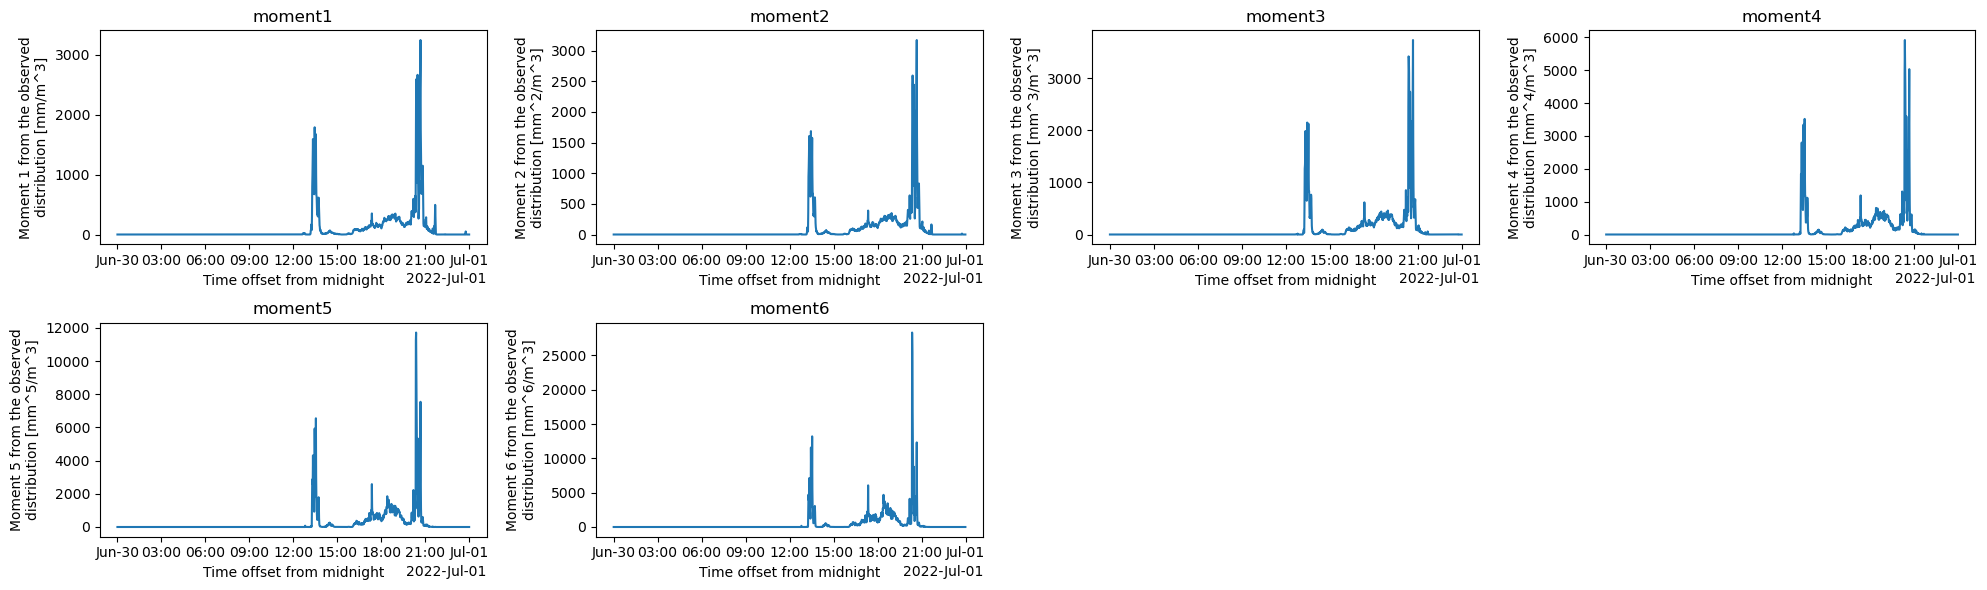

In [78]:
plot_variable_list(moment_vars, ncols=4)

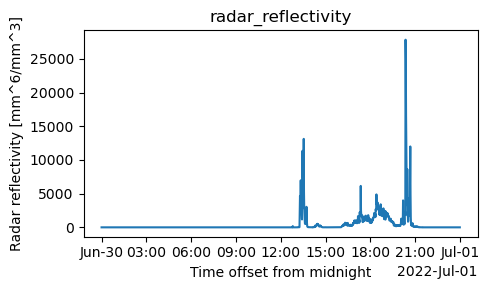

In [79]:
plot_variable_list(radar_vars, ncols=1)